In [1]:
import networkx as nx
import numpy as np
from itertools import combinations

In [58]:
def class_friendship_network(n_s, k, p):
    
    # If large enough for there to be subnetworks...
    if n_s - 1 > 4 * k:

        # Number of subnetworks
        f = (n_s - 1) // (2 * k)
        # Min. number of students in each subnetwork
        n_f = n_s // f
        # Probability that any 2 students in the same subnetwork are friends
        p_f = k / (n_f - 1)
        
        # Create Erdos-Renyi graphs for each subnetwork
        g_list = []
        for snw in range(n_s % f):
            g_list.append(nx.erdos_renyi_graph(n_f+1, p_f))
        for snw in range(n_s % f, n_f):
            g_list.append(nx.erdos_renyi_graph(n_f, p_f))
            
        # Merge graphs
        G = g_list[0]
        for snw in range(1,f):
            G = nx.disjoint_union(G, g_list[snw])

        # Rewire edges of G
        original_edges = list(G.edges)
        all_edges = list(combinations(list(G.nodes), r=2))
        for edge in original_edges:
            # Randomly rewire with probability p
            if np.random.binomial(1, p):
                G.remove_edge(edge[0], edge[1])
                poss_edges = list(set(all_edges).difference(list(G.edges)))
                index = np.random.randint(len(poss_edges))
                new_edge = poss_edges[index]
                G.add_edge(new_edge[0], new_edge[1])
                
    # Else no subnetworks and entire class an ER network
    else:

        # Probability that any 2 students in the same subnetwork are friends
        p_s = k / (n_s - 1)

        # Create an Erdos-Renyi graph for the class
        G = nx.erdos_renyi_graph(n_s, p_s)

    return G

In [68]:
def school_friendship_network(n, s, k, p):

    # Number of students per class
    n_s = n // s

    # For each class
    g_list = []
    for i in range(n % s):
        g_list.append(class_friendship_network(n_s+1, k, p))
    for i in range(n % s, s):
        g_list.append(class_friendship_network(n_s, k, p))

    # Merge classroom graphs
    G = g_list[0]
    for i in range(1,s):
        G = nx.disjoint_union(G, g_list[i])
        
    # Randomly rewire within the entire school
    original_edges = list(G.edges)
    all_edges = list(combinations(list(G.nodes), r=2))
    for edge in original_edges:
        # Randomly rewire with probability p
        if np.random.binomial(1, p):
            G.remove_edge(edge[0], edge[1])
            poss_edges = list(set(all_edges).difference(list(G.edges)))
            index = np.random.randint(len(poss_edges))
            new_edge = poss_edges[index]
            G.add_edge(new_edge[0], new_edge[1])

    return G

In [77]:
G = school_friendship_network(100, 3, 4, 0.1)

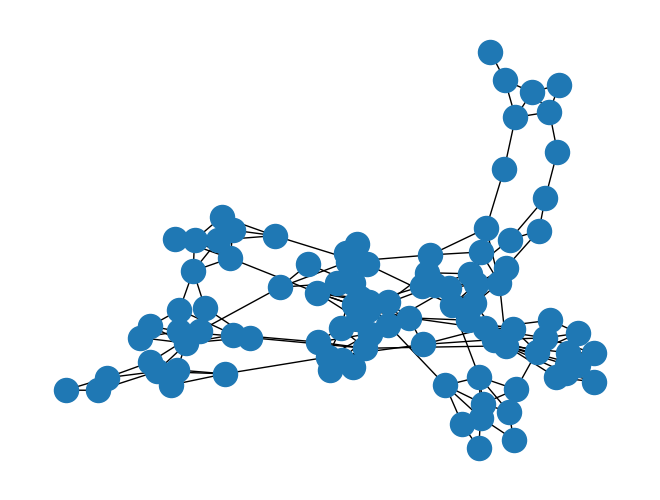

In [78]:
nx.draw(G)